<a href="https://colab.research.google.com/github/Godenzo0n/ml-train/blob/develop/Predicting_customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

advanced_dls_spring_2021_path = kagglehub.competition_download('advanced-dls-spring-2021')

print('Data source import complete.')


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df_train = pd.read_csv('/kaggle/input/advanced-dls-spring-2021/train.csv')
df_test = pd.read_csv('/kaggle/input/advanced-dls-spring-2021/test.csv')

In [ ]:
df_train.sample(5)

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
319,32,19.80,607.7,Male,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0
340,47,110.85,5275.8,Male,0,Yes,No,Yes,Yes,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Credit card (automatic),1
3985,3,20.20,50.6,Male,0,No,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),0
3093,26,19.20,459.6,Female,0,Yes,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0
550,5,56.15,291.45,Male,0,No,No,Yes,No,DSL,No,No,Yes,Yes,No,No,Month-to-month,No,Electronic check,0


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   object 
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non-null   object 
 13  HasTechSupportAccess      5282 non-null   object 
 14  HasOnlin

# Проблема столбца TotalSpent

In [ ]:
'''
TotalSpent - object? Осмотр столбца - основном значения float, но полагаю, что
столбец неспроста такого типа и там могут быть нечисловые признаки
'''
df_train['TotalSpent']

0       1026.35
1        1872.2
2          75.9
3          2570
4       6758.45
         ...   
5277      82.15
5278    2188.45
5279      55.05
5280    2215.25
5281     1375.6
Name: TotalSpent, Length: 5282, dtype: object

In [ ]:
'''
Если в столбце будут нечисловые значения, то в таком случае в новом столбце
будет Nan
'''

new_train_TotalSpent = pd.Series(pd.to_numeric(df_train['TotalSpent'], errors='coerce'))
new_test_TotalSpent = pd.Series(pd.to_numeric(df_test['TotalSpent'], errors='coerce'))

In [ ]:
null_indexes_train = new_train_TotalSpent.loc[new_train_TotalSpent.isnull()==True].index.tolist()
null_indexes_test = new_test_TotalSpent.loc[new_test_TotalSpent.isnull()==True].index.tolist()

print(null_indexes_train, end='\n')
print(null_indexes_test)

[1048, 1707, 2543, 3078, 3697, 4002, 4326, 4551, 4598]
[177, 767]


Надо-бы заполнить пустоты. Хотелось бы узнать, какие значения там были прежде

In [ ]:
df_train.loc[null_indexes_train]

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
1048,0,25.75,,Male,0,Yes,Yes,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,0
1707,0,73.35,,Female,0,Yes,Yes,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,0
2543,0,19.70,,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,0
3078,0,80.85,,Female,0,Yes,Yes,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,0
3697,0,20.00,,Female,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,0
4002,0,61.90,,Male,0,No,Yes,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),0
4326,0,25.35,,Male,0,Yes,Yes,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,0
4551,0,52.55,,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),0
4598,0,56.05,,Female,0,Yes,Yes,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),0


Теперь стало понятно, почему TotalSpent был строковым столбцом, в некоторых строках принимал значение ' ' (пробел) и по-факту TotalSpent был пустым в этих строках. Метод Pandas info() (и в целом все методы Pandas на поиск пустых строк) не уловил эти пробелы как пустое значение, он считает пустыми только те, что принимают значение Nan

Мысли насчет того, как заполнять пустые строки в новом столбце. Признак 'MonthlySpending' у этих объектов не равен 0. Значит, пропуск в столбце 'TotalSpent' - ошибка и заполнить '0' данный пропуск нельзя.

In [ ]:
value = new_train_TotalSpent.sum() / df_train['MonthlySpending'].sum()
print(f'В среднем значение TotalSpent больше MonthlySpending в {value:.2f} раз')

В среднем значение TotalSpent больше MonthlySpending в 35.23 раз


Идея - заполнить пропуски так: умножить значение из столбца 'MonthlySpending', на value (переменная в ячейке выше)

In [ ]:
for elem in null_indexes_train:
    new_train_TotalSpent.loc[elem] = df_train['MonthlySpending'].loc[elem] * value
for elem in null_indexes_test:
    new_test_TotalSpent.loc[elem] = df_test['MonthlySpending'].loc[elem] * value


df_train['TotalSpent'] = new_train_TotalSpent
df_test['TotalSpent'] = new_test_TotalSpent

In [ ]:
'''
Изучил решения коллег и оказалось, что
все это можно было сделать в несколько строк без большого количества действий!

1. Если знать, что есть пробелы, то надо заменить их (в тестовой и тренировочной выборке) на Nan
перед переводом в числовой тип:
df['TotalSpent'] = df['TotalSpent'].replace(' ', np.nan)


2. Перевести выборку из O в float64 (и train и test):
df['TotalSpent'] = df['TotalSpent'].astype('float64')
Я реализовывал перевод из o в float как во втором шаге, но была ошибка, т.к. не был обработан ' '

3. Заполнить пропуски произвольным образом (train\test, например нулями):
df['TotalSpent'] = df['TotalSpent'].fillna(0)

'''


"\nИзучил решения коллег и оказалось, что \nвсе это можно было сделать в несколько строк без большого количества действий!\n\n1. Если знать, что есть пробелы, то надо заменить их (в тестовой и тренировочной выборке) на Nan \nперед переводом в числовой тип:\ndf['TotalSpent'] = df['TotalSpent'].replace(' ', np.nan) \n\n  \n2. Перевести выборку из O в float64 (и train и test):\ndf['TotalSpent'] = df['TotalSpent'].astype('float64')\nЯ реализовывал перевод из o в float как во втором шаге, но была ошибка, т.к. не был обработан ' '\n\n3. Заполнить пропуски произвольным образом (train\test, например нулями):\ndf['TotalSpent'] = df['TotalSpent'].fillna(0)\n\n"

# Анализ датасетов

In [ ]:
cat_columns = df_train.select_dtypes(include='object').columns.tolist()

for column in cat_columns:
    print(df_train[column].value_counts())
    print()

Sex
Male      2655
Female    2627
Name: count, dtype: int64

HasPartner
No     2705
Yes    2577
Name: count, dtype: int64

HasChild
No     3676
Yes    1606
Name: count, dtype: int64

HasPhoneService
Yes    4761
No      521
Name: count, dtype: int64

HasMultiplePhoneNumbers
No                  2511
Yes                 2250
No phone service     521
Name: count, dtype: int64

HasInternetService
Fiber optic    2341
DSL            1800
No             1141
Name: count, dtype: int64

HasOnlineSecurityService
No                     2612
Yes                    1529
No internet service    1141
Name: count, dtype: int64

HasOnlineBackup
No                     2332
Yes                    1809
No internet service    1141
Name: count, dtype: int64

HasDeviceProtection
No                     2317
Yes                    1824
No internet service    1141
Name: count, dtype: int64

HasTechSupportAccess
No                     2604
Yes                    1537
No internet service    1141
Name: count, dtype:

In [ ]:
'''
В датасете есть столбцы с признаками Yes/No, то есть бинарные.
Далее их надо преобразовать как 1/0
'''
bin_columns = []
for column in df_train.columns:
        if len(np.unique(df_train[column])) == 2:
            unique_val = np.unique(df_train[column]).tolist()
            if 'Yes' in unique_val and 'No' in unique_val:
                bin_columns.append(column)
bin_columns

['HasPartner', 'HasChild', 'HasPhoneService', 'IsBillingPaperless']

In [ ]:
'''
В датасете есть признаки Yes/No/No internet service (No phone service) (Назову их trinity-троичными)
Далее я их проебразую так: 0/1/-1
'''
trin_columns = []
for column in df_train.columns:
    if len(np.unique(df_train[column])) == 3:
        unique_val = np.unique(df_train[column]).tolist()
        if 'No internet service' in unique_val:
            trin_columns.append(column)
trin_columns

['HasOnlineSecurityService',
 'HasOnlineBackup',
 'HasDeviceProtection',
 'HasTechSupportAccess',
 'HasOnlineTV',
 'HasMovieSubscription']

In [ ]:
num_columns = df_train.select_dtypes(exclude='object').columns.tolist()
cat_columns = df_train.select_dtypes(include='object').columns.tolist()

cat_columns = [x for x in cat_columns if x not in bin_columns and x not in trin_columns]
# отделение категориальные от бинарных и троичных
print(f'Категориальные признаки: {cat_columns} \n\nКоличественные признаки: {num_columns} \n\nБинарные признаки: {bin_columns} \n\nТроичные признаки: {trin_columns}')


Категориальные признаки: ['Sex', 'HasMultiplePhoneNumbers', 'HasInternetService', 'HasContractPhone', 'PaymentMethod'] 

Количественные признаки: ['ClientPeriod', 'MonthlySpending', 'TotalSpent', 'IsSeniorCitizen', 'Churn'] 

Бинарные признаки: ['HasPartner', 'HasChild', 'HasPhoneService', 'IsBillingPaperless'] 

Троичные признаки: ['HasOnlineSecurityService', 'HasOnlineBackup', 'HasDeviceProtection', 'HasTechSupportAccess', 'HasOnlineTV', 'HasMovieSubscription']


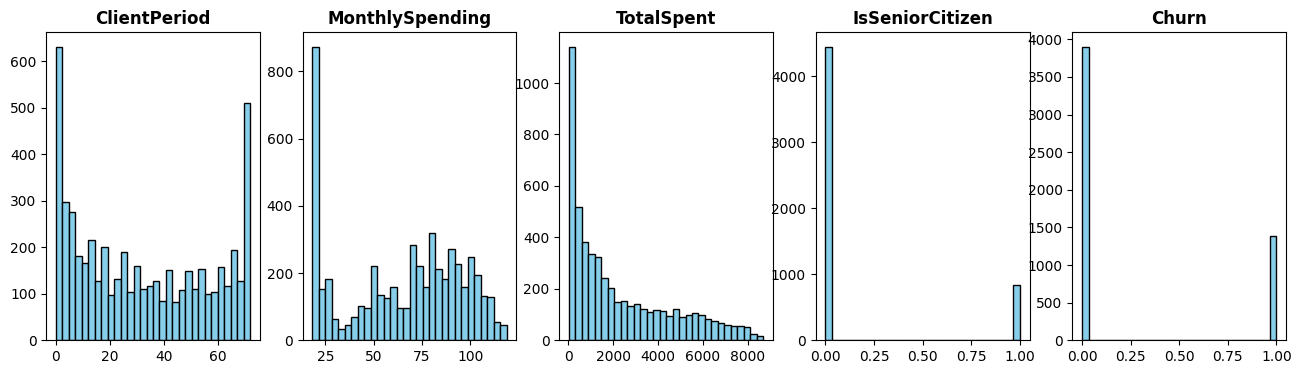

In [ ]:

fig, axes = plt.subplots(1, 5, figsize=(16, 4))

for i, col in enumerate(num_columns):
    axes[i].hist(df_train[col], bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(col, fontsize=12, fontweight='bold')

In [ ]:

#fig, axis = plt.subplots(1, 5, figsize = (16, 4))

#for i, column in enumerate(num_columns):
#    axis[i].hist(df_test[column], bins=30, color='skyblue', edgecolor='black')
#    axis[i].set_title(column, fontsize=12, fontweight='bold')

In [ ]:
df_train[num_columns].describe()

,ClientPeriod,MonthlySpending,TotalSpent,IsSeniorCitizen,Churn
count,5282.000000,5282.000000,5282.000000,5282.000000,5282.000000
mean,32.397009,64.924754,2290.257698,0.159409,0.262022
std,24.550326,30.176464,2267.482322,0.366092,0.439776
min,0.000000,18.250000,18.800000,0.000000,0.000000
25%,9.000000,35.462500,401.587500,0.000000,0.000000
50%,29.000000,70.400000,1410.725000,0.000000,0.000000
75%,55.000000,90.050000,3795.212500,0.000000,1.000000
max,72.000000,118.750000,8684.800000,1.000000,1.000000


In [ ]:
for column in cat_columns:
    print(df_train[column].value_counts())
    print()

Sex
Male      2655
Female    2627
Name: count, dtype: int64

HasMultiplePhoneNumbers
No                  2511
Yes                 2250
No phone service     521
Name: count, dtype: int64

HasInternetService
Fiber optic    2341
DSL            1800
No             1141
Name: count, dtype: int64

HasContractPhone
Month-to-month    2920
Two year          1280
One year          1082
Name: count, dtype: int64

PaymentMethod
Electronic check             1786
Mailed check                 1194
Bank transfer (automatic)    1159
Credit card (automatic)      1143
Name: count, dtype: int64



# Обработка пустых значений

In [ ]:
print('Пропуски в каждом столбце тренировочной выборки:')
print(df_train.isnull().sum(), end='\n')
print('Пропуски в каждом столбце тестовой выборки:')
print(df_test.isnull().sum(), end='\n')

Пропуски в каждом столбце тренировочной выборки:
ClientPeriod                0
MonthlySpending             0
TotalSpent                  0
Sex                         0
IsSeniorCitizen             0
HasPartner                  0
HasChild                    0
HasPhoneService             0
HasMultiplePhoneNumbers     0
HasInternetService          0
HasOnlineSecurityService    0
HasOnlineBackup             0
HasDeviceProtection         0
HasTechSupportAccess        0
HasOnlineTV                 0
HasMovieSubscription        0
HasContractPhone            0
IsBillingPaperless          0
PaymentMethod               0
Churn                       0
dtype: int64
Пропуски в каждом столбце тестовой выборки:
ClientPeriod                0
MonthlySpending             0
TotalSpent                  0
Sex                         0
IsSeniorCitizen             0
HasPartner                  0
HasChild                    0
HasPhoneService             0
HasMultiplePhoneNumbers     0
HasInternetService      

Пропусков нет (были заполнены при решении проблемы со столбцом TotalSpent)  

# Обработка категориальных признаков
Т.к. модели могут работать только с числовыми признаками, то категориальные надо преобразовать в числовые

In [ ]:
for column in bin_columns:
       df_train[column] = df_train[column].map({'Yes': 1, 'No': 0})
       df_test[column] = df_test[column].map({'Yes': 1, 'No': 0})
df_train

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
0,55,19.50,1026.35,Male,0,1,1,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,0,Mailed check,0
1,72,25.85,1872.20,Male,0,1,0,1,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Credit card (automatic),0
2,1,75.90,75.90,Male,0,0,0,1,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,1,Electronic check,1
3,32,79.30,2570.00,Female,1,1,0,1,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,0,Mailed check,0
4,60,115.25,6758.45,Female,0,1,1,1,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,0,Credit card (automatic),0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5277,3,30.40,82.15,Male,0,0,0,0,No phone service,DSL,No,No,No,Yes,No,No,Month-to-month,0,Electronic check,0
5278,50,44.45,2188.45,Male,0,1,0,0,No phone service,DSL,Yes,No,No,Yes,Yes,No,One year,1,Bank transfer (automatic),0
5279,1,55.05,55.05,Male,0,0,0,1,No,DSL,No,No,Yes,Yes,No,No,Month-to-month,0,Mailed check,0
5280,29,76.00,2215.25,Female,0,0,0,1,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Credit card (automatic),0


In [ ]:
for column in trin_columns:
    df_train[column] = df_train[column].map({'Yes': 1, 'No': 0, 'No internet service': -1})
    df_test[column] = df_test[column].map({'Yes': 1, 'No': 0, 'No internet service': -1})
df_train

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
0,55,19.50,1026.35,Male,0,1,1,1,No,No,-1,-1,-1,-1,-1,-1,One year,0,Mailed check,0
1,72,25.85,1872.20,Male,0,1,0,1,Yes,No,-1,-1,-1,-1,-1,-1,Two year,0,Credit card (automatic),0
2,1,75.90,75.90,Male,0,0,0,1,No,Fiber optic,0,0,0,1,0,0,Month-to-month,1,Electronic check,1
3,32,79.30,2570.00,Female,1,1,0,1,Yes,Fiber optic,0,0,1,0,0,0,Month-to-month,0,Mailed check,0
4,60,115.25,6758.45,Female,0,1,1,1,Yes,Fiber optic,1,1,1,1,1,1,Two year,0,Credit card (automatic),0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5277,3,30.40,82.15,Male,0,0,0,0,No phone service,DSL,0,0,0,1,0,0,Month-to-month,0,Electronic check,0
5278,50,44.45,2188.45,Male,0,1,0,0,No phone service,DSL,1,0,0,1,1,0,One year,1,Bank transfer (automatic),0
5279,1,55.05,55.05,Male,0,0,0,1,No,DSL,0,0,1,1,0,0,Month-to-month,0,Mailed check,0
5280,29,76.00,2215.25,Female,0,0,0,1,Yes,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Credit card (automatic),0


In [ ]:
#encoder = OneHotEncoder(handle_unknown='ignore')
#encoder.fit(df_test[cat_columns])
#df_train_one_hot_array = encoder.transform(df_train[cat_columns]).toarray()
#df_test_one_hot_array = encoder.transform(df_test[cat_columns]).toarray()


In [ ]:
#encoded_columns = encoder.get_feature_names_out()
#encoded_columns

In [ ]:
#df_train_encoded = pd.DataFrame(df_train_one_hot_array, columns=encoded_columns)
#df_test_encoded = pd.DataFrame(df_test_one_hot_array, columns=encoded_columns)
#print(f'Размер тренировочной OneHotEncoded выборки: {df_train_encoded.shape}\nРазмер тестовой OneHotEncoded выборки: {df_test_encoded.shape}')

In [ ]:
#df_test_droped_categorial = df_test.drop(cat_columns, axis=1)
#df_train_droped_categorial = df_train.drop(cat_columns, axis=1)

#df_train = pd.concat([df_train_droped_categorial, df_train_encoded], axis=1)
#df_test = pd.concat([df_test_droped_categorial, df_test_encoded], axis=1)

## Разделение выборки на матрицу объект-признак (X) и  вектор целевого значения (y)

In [ ]:
print(f'Столбцы тестовой выборки {df_test.shape[1]} \nСтолбцы тренировочной выборки {df_train.shape[1]}')

Столбцы тестовой выборки 19 
Столбцы тренировочной выборки 20


In [ ]:
num_cols = df_train.select_dtypes(exclude='object').columns.tolist()
cat_cols = df_train.select_dtypes(include='object').columns.tolist()

num_cols.remove('Churn')

In [ ]:
X = df_train.drop(['Churn'], axis=1)
y = df_train['Churn']

Решил убрать этап OHE (изменил ячейки, сделал его комментариями), поскольку для catboost не требуется предварительная обработка категориальных данных, а для модели linreg можно отдельно предобработать выборку с ohe ( и scaler, кстати)

Статья про catboost и о том, почему не надо препроцессить данные когда используешь этот бустинг:
https://neerc.ifmo.ru/wiki/index.php?title=CatBoost

# Создание моделей

In [ ]:
from sklearn.model_selection import KFold

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier

from sklearn.metrics import roc_auc_score


## Оценка качества модели

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
def catboost_find_hyperp():

    catboost = CatBoostClassifier(
        cat_features=cat_cols,
        loss_function='Logloss',
        eval_metric="AUC",
        verbose=False
    )

    catboost_params_grid = {
        'learning_rate': [0.01, 0.05, 0.1, 0.5, 1],
        'depth': [6, 8, 10],
        'l2_leaf_reg': [1, 3, 5],
        'iterations': [1000],
        'random_strength': [1, 10],
        'bagging_temperature': [0, 1]
                           }


    catboost.grid_search(catboost_params_grid, X_train, y_train, cv=10, refit=True)

    return catboost

In [ ]:
best_catboost = catboost_find_hyperp()


bestTest = 0.8371974916
bestIteration = 226

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
0:	loss: 0.8371975	best: 0.8371975 (0)	total: 6.33s	remaining: 18m 54s

bestTest = 0.8363436966
bestIteration = 47

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
1:	loss: 0.8363437	best: 0.8371975 (0)	total: 12.3s	remaining: 18m 18s

bestTest = 0.8349415592
bestIteration = 10

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
2:	loss: 0.8349416	best: 0.8371975 (0)	total: 18.6s	remaining: 18m 15s

bestTest = 0.8367264323
bestIteration = 5

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
3:	loss: 0.8367264	best: 0.8371975 (0)	total: 24.5s	remaining: 18m

bes

In [ ]:
print(f'{best_catboost.best_score_} \n\nПараметры catboost: \n{best_catboost.get_params()}')

{'learn': {'CrossEntropy': 0.39007373033718384, 'AUC': 0.8658702104061498}} 

Параметры catboost: 
{'loss_function': 'CrossEntropy', 'random_seed': 42, 'logging_level': 'Silent', 'metric_period': 1000, 'eval_metric': 'AUC:hints=skip_train~false', 'early_stopping_rounds': 10, 'cat_features': ['Sex', 'HasMultiplePhoneNumbers', 'HasInternetService', 'HasContractPhone', 'PaymentMethod'], 'grow_policy': 'Lossguide', 'subsample': 1, 'depth': 3, 'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 100}


In [ ]:
print(roc_auc_score(y_train, y_hat_train))
print(roc_auc_score(y_test, y_hat_test))

0.9115306814037744
0.8281439033625475


In [ ]:
catboost = best_catboost
y_hat_train = catboost.predict_proba(X_train)[:, 1]
y_hat_test = catboost.predict_proba(X_test)[:, 1]

print(roc_auc_score(y_train, y_hat_train))
print(roc_auc_score(y_test, y_hat_test))

0.8656113408630647
0.8356752338822138


# Прогноз модели

In [ ]:
y_hat = catboost.predict_proba(df_test)[:, 1]

In [ ]:
submit = pd.DataFrame({
    'Id': range(len(y_hat)),
    'Churn': y_hat
})
submit.to_csv('submission.csv', index=False)
submit

,Id,Churn
0,0,0.054131
1,1,0.654495
2,2,0.694068
3,3,0.023678
4,4,0.011387
...,...,...
1756,1756,0.092765
1757,1757,0.017746
1758,1758,0.797240
1759,1759,0.697851
